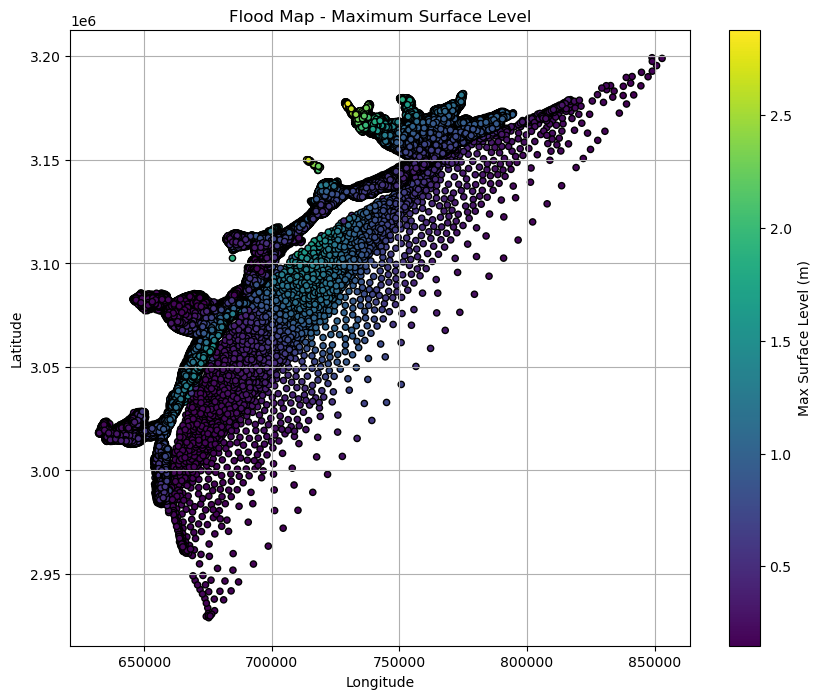

In [10]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# Specify the path to your .dfsu file
dfsu_file = r'D:\Phd Research\Prototype HD Model\Simulation\test_run_Hurricane_Harvey.m21fm - Result Files\area v3.dfsu'

# Load the .dfsu file
dfs = mikeio.open(dfsu_file)


# Read the surface elevation data
data = dfs.read()

# Extract the surface elevation DataArray
surface_elevation = data['Surface elevation']  # Ensure this matches the item name in your file

# Check if the data is node-based or element-based
if surface_elevation.shape[1] == dfs.geometry.node_coordinates.shape[0]:
    # Node-based data
    max_surface_levels = np.max(surface_elevation.values, axis=0)
else:
    # Element-based data, interpolate to nodes
    element_values = surface_elevation.values
    num_nodes = dfs.geometry.node_coordinates.shape[0]
    num_elements = element_values.shape[1]
    
    # Initialize array to hold node values
    node_values = np.zeros((element_values.shape[0], num_nodes))
    node_count = np.zeros(num_nodes)
    
    # Map element values to nodes
    for element_index in range(num_elements):
        nodes = dfs.geometry.element_table[element_index]
        for node in nodes:
            node_values[:, node] += element_values[:, element_index]
            node_count[node] += 1
    
    # Average the values at each node
    node_values /= node_count
    
    # Calculate the maximum surface levels across the time dimension
    max_surface_levels = np.max(node_values, axis=0)

# Extract the coordinates
x_coords = dfs.geometry.node_coordinates[:, 0]
y_coords = dfs.geometry.node_coordinates[:, 1]

# Ensure the sizes match
assert max_surface_levels.shape[0] == x_coords.shape[0] == y_coords.shape[0], "Data and coordinates size mismatch"

# Plot the flood map
plt.figure(figsize=(10, 8))
sc = plt.scatter(x_coords, y_coords, c=max_surface_levels, cmap='viridis', marker='o', edgecolor='k', s=20)
plt.colorbar(sc, label='Max Surface Level (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flood Map - Maximum Surface Level')
plt.grid(True)
plt.show()